# PokerMind AI — Data Exploration Notebook

PokerMind AI analyzes poker hand histories.

The first objective is to understand which player has the highest chance of winning during a hand. Later, the project will analyze whether decisions were reasonable using equity, pot odds, stacks, position, and betting history.

The objective of this notebook is to inspect raw PHH files and create a first hand-level feature table. No model is trained yet in this notebook.

## 2. Imports and Paths

In [32]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path("..")
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FEATURE_FILE = PROCESSED_DATA_DIR / "hand_level_features.csv"

sns.set_theme(style="whitegrid")

pd.DataFrame(
    {
        "name": ["PROJECT_ROOT", "RAW_DATA_DIR", "PROCESSED_DATA_DIR", "FEATURE_FILE"],
        "path": [PROJECT_ROOT, RAW_DATA_DIR, PROCESSED_DATA_DIR, FEATURE_FILE],
    }
)

,name,path
0,PROJECT_ROOT,..
1,RAW_DATA_DIR,../data/raw
2,PROCESSED_DATA_DIR,../data/processed
3,FEATURE_FILE,../data/processed/hand_level_features.csv


## 3. Raw Data File Inventory

In [33]:
all_raw_files = sorted([path for path in RAW_DATA_DIR.rglob("*") if path.is_file() and not path.name.startswith(".")])

files_df = pd.DataFrame(
    [
        {
            "file_name": path.name,
            "relative_path": str(path.relative_to(RAW_DATA_DIR)),
            "extension": path.suffix.lower(),
            "parent_folder": str(path.parent.relative_to(RAW_DATA_DIR)),
            "size_bytes": path.stat().st_size,
            "size_kb": round(path.stat().st_size / 1024, 2),
        }
        for path in all_raw_files
    ]
)

files_df.head(20)

,file_name,relative_path,extension,parent_folder,size_bytes,size_kb
0,alice-carol-wikipedia.phh,alice-carol-wikipedia.phh,.phh,.,1235,1.21
1,antonius-blom-2009.phh,antonius-blom-2009.phh,.phh,.,858,0.84
2,arieh-yockey-2019.phh,arieh-yockey-2019.phh,.phh,.,1336,1.30
3,dwan-ivey-2009.phh,dwan-ivey-2009.phh,.phh,.,921,0.90
4,abs NLH handhq_1-OBFUSCATED.phhs,handhq/ABS-2009-07-01_2009-07-23_1000NLH_OBFU/...,.phhs,handhq/ABS-2009-07-01_2009-07-23_1000NLH_OBFU/10,636240,621.33
5,abs NLH handhq_10-OBFUSCATED.phhs,handhq/ABS-2009-07-01_2009-07-23_1000NLH_OBFU/...,.phhs,handhq/ABS-2009-07-01_2009-07-23_1000NLH_OBFU/10,681457,665.49
6,abs NLH handhq_11-OBFUSCATED.phhs,handhq/ABS-2009-07-01_2009-07-23_1000NLH_OBFU/...,.phhs,handhq/ABS-2009-07-01_2009-07-23_1000NLH_OBFU/10,628676,613.94
7,abs NLH handhq_12-OBFUSCATED.phhs,handhq/ABS-2009-07-01_2009-07-23_1000NLH_OBFU/...,.phhs,handhq/ABS-2009-07-01_2009-07-23_1000NLH_OBFU/10,685460,669.39
8,abs NLH handhq_13-OBFUSCATED.phhs,handhq/ABS-2009-07-01_2009-07-23_1000NLH_OBFU/...,.phhs,handhq/ABS-2009-07-01_2009-07-23_1000NLH_OBFU/10,713443,696.72
9,abs NLH handhq_14-OBFUSCATED.phhs,handhq/ABS-2009-07-01_2009-07-23_1000NLH_OBFU/...,.phhs,handhq/ABS-2009-07-01_2009-07-23_1000NLH_OBFU/10,719299,702.44


In [34]:
inventory_summary_df = pd.DataFrame(
    {
        "metric": [
            "total_number_of_files",
            "number_of_phh_files",
            "number_of_phhs_files",
            "total_visible_file_size_bytes",
            "total_visible_file_size_kb",
        ],
        "value": [
            len(files_df),
            int((files_df["extension"] == ".phh").sum()),
            int((files_df["extension"] == ".phhs").sum()),
            int(files_df["size_bytes"].sum()),
            round(files_df["size_kb"].sum(), 2),
        ],
    }
)

inventory_summary_df

,metric,value
0,total_number_of_files,3.187000e+04
1,number_of_phh_files,1.008800e+04
2,number_of_phhs_files,2.178200e+04
3,total_visible_file_size_bytes,1.631385e+10
4,total_visible_file_size_kb,1.593149e+07


`.phh` files usually represent individual poker hand histories, while `.phhs` files may contain several hand histories grouped inside one source file.

## 4. PHH File Selection and Raw Inspection

In [35]:
phh_files_df = files_df[files_df["extension"].isin([".phh", ".phhs"])].reset_index(drop=True).copy()
phh_files_df.insert(0, "index", phh_files_df.index)
phh_files_df

,index,file_name,relative_path,extension,parent_folder,size_bytes,size_kb
0,0,alice-carol-wikipedia.phh,alice-carol-wikipedia.phh,.phh,.,1235,1.21
1,1,antonius-blom-2009.phh,antonius-blom-2009.phh,.phh,.,858,0.84
2,2,arieh-yockey-2019.phh,arieh-yockey-2019.phh,.phh,.,1336,1.30
3,3,dwan-ivey-2009.phh,dwan-ivey-2009.phh,.phh,.,921,0.90
4,4,abs NLH handhq_1-OBFUSCATED.phhs,handhq/ABS-2009-07-01_2009-07-23_1000NLH_OBFU/...,.phhs,handhq/ABS-2009-07-01_2009-07-23_1000NLH_OBFU/10,636240,621.33
...,...,...,...,...,...,...,...
31865,31865,82.phh,wsop/2023/43/5/82.phh,.phh,wsop/2023/43/5,726,0.71
31866,31866,83.phh,wsop/2023/43/5/83.phh,.phh,wsop/2023/43/5,549,0.54
31867,31867,84.phh,wsop/2023/43/5/84.phh,.phh,wsop/2023/43/5,657,0.64
31868,31868,85.phh,wsop/2023/43/5/85.phh,.phh,wsop/2023/43/5,877,0.86


In [36]:
SELECTED_FILE_INDEX = 0
selected_file_row = phh_files_df.iloc[SELECTED_FILE_INDEX]
selected_file_path = RAW_DATA_DIR / selected_file_row["relative_path"]
selected_text = selected_file_path.read_text(encoding="utf-8")
selected_lines = selected_text.splitlines()

pd.DataFrame(
    {
        "selected_file_name": [selected_file_row["file_name"]],
        "selected_relative_path": [selected_file_row["relative_path"]],
        "selected_extension": [selected_file_row["extension"]],
        "line_count": [len(selected_lines)],
    }
)

,selected_file_name,selected_relative_path,selected_extension,line_count
0,alice-carol-wikipedia.phh,alice-carol-wikipedia.phh,.phh,68


In [37]:
print("\n".join(selected_lines[:120]))

# An example badugi hand from Wikipedia.
# Link: https://en.wikipedia.org/wiki/Badugi

variant = "FB"
ante_trimming_status = true
antes = [0, 0, 0, 0]
blinds_or_straddles = [1, 2, 0, 0]
small_bet = 2
big_bet = 4
starting_stacks = [200, 200, 200, 200]
actions = [
  # Pre-draw

  "d dh p1 ????????",  # Bob
  "d dh p2 ????????",  # Carol
  "d dh p3 ????????",  # Ted
  "d dh p4 ????????",  # Alice

  "p3 f",  # Ted
  "p4 cc",  # Alice
  "p1 cc",  # Bob
  "p2 cc",  # Carol

  # First draw

  "p1 sd ????",  # Bob
  "p2 sd ????",  # Carol
  "p4 sd ??",  # Alice
  "d dh p1 ????",  # Bob
  "d dh p2 ????",  # Carol
  "d dh p4 ??",  # Alice

  "p1 cc",  # Bob
  "p2 cbr 2",  # Carol
  "p4 cc",  # Alice
  "p1 cc",  # Bob

  # Second draw

  "p1 sd ??",  # Bob
  "p2 sd",  # Carol
  "p4 sd ??",  # Alice
  "d dh p1 ??",  # Bob
  "d dh p4 ??",  # Alice

  "p1 cc",  # Bob
  "p2 cbr 4",  # Carol
  "p4 cbr 8",  # Alice
  "p1 f",  # Bob
  "p2 cc",  # Bob

  # Third draw

  "p2 sd ??",  # Carol
  "p4 sd",  

In [38]:
action_keywords = ["fold", "call", "raise", "bet", "check", "all-in", "posts", "dealt", "shows", "collected", "cbr", "cc", "f", "sm"]
card_keywords = ["hole", "board", "flop", "turn", "river", "cards", "dealt", "dh", "db"]
player_keywords = ["player", "players", "seat", "seats", "stack", "starting_stacks", "p1", "p2", "p3"]

phh_lines_df = pd.DataFrame(
    [
        {
            "line_number": line_number,
            "raw_line": raw_line,
            "stripped_line": raw_line.strip(),
            "is_empty": raw_line.strip() == "",
            "contains_equals": "=" in raw_line,
            "contains_action_keyword": any(keyword in raw_line.lower() for keyword in action_keywords),
            "contains_card_keyword": any(keyword in raw_line.lower() for keyword in card_keywords),
            "contains_player_keyword": any(keyword in raw_line.lower() for keyword in player_keywords),
        }
        for line_number, raw_line in enumerate(selected_lines, start=1)
    ]
)

phh_lines_df.head(100)

,line_number,raw_line,stripped_line,is_empty,contains_equals,contains_action_keyword,contains_card_keyword,contains_player_keyword
0,1,# An example badugi hand from Wikipedia.,# An example badugi hand from Wikipedia.,False,False,True,False,False
1,2,# Link: https://en.wikipedia.org/wiki/Badugi,# Link: https://en.wikipedia.org/wiki/Badugi,False,False,False,False,False
2,3,,,True,False,False,False,False
3,4,"variant = ""FB""","variant = ""FB""",False,True,True,False,False
4,5,ante_trimming_status = true,ante_trimming_status = true,False,True,False,False,False
...,...,...,...,...,...,...,...,...
63,64,"""p4 sm 2s4c6d9h"", # Alice","""p4 sm 2s4c6d9h"", # Alice",False,False,True,False,False
64,65,"""p2 sm 3s5d7c8h"", # Carol","""p2 sm 3s5d7c8h"", # Carol",False,False,True,False,True
65,66,],],False,False,False,False,False
66,67,"author = ""Juho Kim""","author = ""Juho Kim""",False,True,False,False,False


In [39]:
phh_lines_df[~phh_lines_df["is_empty"]].head(50)

,line_number,raw_line,stripped_line,is_empty,contains_equals,contains_action_keyword,contains_card_keyword,contains_player_keyword
0,1,# An example badugi hand from Wikipedia.,# An example badugi hand from Wikipedia.,False,False,True,False,False
1,2,# Link: https://en.wikipedia.org/wiki/Badugi,# Link: https://en.wikipedia.org/wiki/Badugi,False,False,False,False,False
3,4,"variant = ""FB""","variant = ""FB""",False,True,True,False,False
4,5,ante_trimming_status = true,ante_trimming_status = true,False,True,False,False,False
5,6,"antes = [0, 0, 0, 0]","antes = [0, 0, 0, 0]",False,True,False,False,False
6,7,"blinds_or_straddles = [1, 2, 0, 0]","blinds_or_straddles = [1, 2, 0, 0]",False,True,False,False,False
7,8,small_bet = 2,small_bet = 2,False,True,True,False,False
8,9,big_bet = 4,big_bet = 4,False,True,True,False,False
9,10,"starting_stacks = [200, 200, 200, 200]","starting_stacks = [200, 200, 200, 200]",False,True,False,False,True
10,11,actions = [,actions = [,False,True,False,False,False


PHH files are structured text, not classical CSV tables. The structure is readable line by line, and meaningful information is stored in fields such as `variant`, `players`, `starting_stacks`, `actions`, and `finishing_stacks`.

## 5. PHH Grammar Notes

PHH uses a compact action grammar. A few short codes describe deals, actions, and results.

In [40]:
action_glossary_df = pd.DataFrame(
    [
        ["d db card(s)", "dealer deals board/community cards", "community cards visible to everyone"],
        ["d dh pN card(s)", "dealer deals private hole cards to player pN", "private or down cards"],
        ["pN cbr amount", "player completes, bets, or raises to amount", "betting action with amount"],
        ["pN cc", "player checks or calls", "passive action"],
        ["pN f", "player folds", "player leaves the hand"],
        ["pN sd card(s)", "player stands pat or discards, depending on variant", "mainly relevant in draw games"],
        ["pN sm card(s)", "player shows or mucks cards", "showdown-related action"],
        ["pN", "player identifier", "for example p1, p2, p3"],
        ["# comment", "human-readable comment", "helps indicate streets or notes"],
    ],
    columns=["code", "meaning", "notes"],
)

action_glossary_df

,code,meaning,notes
0,d db card(s),dealer deals board/community cards,community cards visible to everyone
1,d dh pN card(s),dealer deals private hole cards to player pN,private or down cards
2,pN cbr amount,"player completes, bets, or raises to amount",betting action with amount
3,pN cc,player checks or calls,passive action
4,pN f,player folds,player leaves the hand
5,pN sd card(s),"player stands pat or discards, depending on va...",mainly relevant in draw games
6,pN sm card(s),player shows or mucks cards,showdown-related action
7,pN,player identifier,"for example p1, p2, p3"
8,# comment,human-readable comment,helps indicate streets or notes


In [41]:
card_notation_df = pd.DataFrame(
    [
        ["Ranks", "A, K, Q, J, T, 9, 8, 7, 6, 5, 4, 3, 2, ?"],
        ["Suits", "c, d, h, s, ?"],
    ],
    columns=["notation_type", "values"],
)

card_notation_df

,notation_type,values
0,Ranks,"A, K, Q, J, T, 9, 8, 7, 6, 5, 4, 3, 2, ?"
1,Suits,"c, d, h, s, ?"


## 6. Simple Structure Extraction From Selected File

In [42]:
metadata_rows = []

for raw_line in selected_lines:
    stripped_line = raw_line.strip()
    if "=" in stripped_line:
        key, value = stripped_line.split("=", 1)
        metadata_rows.append({"key": key.strip(), "value": value.strip()})

metadata_df = pd.DataFrame(metadata_rows)
metadata_df

,key,value
0,variant,"""FB"""
1,ante_trimming_status,true
2,antes,"[0, 0, 0, 0]"
3,blinds_or_straddles,"[1, 2, 0, 0]"
4,small_bet,2
5,big_bet,4
6,starting_stacks,"[200, 200, 200, 200]"
7,actions,[
8,author,"""Juho Kim"""
9,players,"[""Bob"", ""Carol"", ""Ted"", ""Alice""]"


In [43]:
import re

quoted_actions = re.findall(r"['\"]([^'\"]+)['\"]", selected_text)
action_strings = [action for action in quoted_actions if action.startswith("d ") or re.match(r"p\d+\s", action)]

actions_df = pd.DataFrame(
    [
        {
            "action_index": index,
            "raw_action": action,
            "player_guess": re.search(r"\bp\d+\b", action).group(0) if re.search(r"\bp\d+\b", action) else "",
            "action_code_guess": "d dh" if action.startswith("d dh") else "d db" if action.startswith("d db") else action.split()[1] if len(action.split()) > 1 else action.split()[0],
            "amount_guess": re.findall(r"\d+(?:\.\d+)?", action)[-1] if re.findall(r"\d+(?:\.\d+)?", action) else "",
            "is_deal_hole": action.startswith("d dh"),
            "is_deal_board": action.startswith("d db"),
            "is_fold": bool(re.match(r"^p\d+\s+f\b", action)),
            "is_check_call": bool(re.match(r"^p\d+\s+cc\b", action)),
            "is_bet_raise": bool(re.match(r"^p\d+\s+cbr\b", action)),
            "is_show_muck": bool(re.match(r"^p\d+\s+sm\b", action)),
        }
        for index, action in enumerate(action_strings)
    ]
)

actions_df

,action_index,raw_action,player_guess,action_code_guess,amount_guess,is_deal_hole,is_deal_board,is_fold,is_check_call,is_bet_raise,is_show_muck
0,0,d dh p1 ????????,p1,d dh,1,True,False,False,False,False,False
1,1,d dh p2 ????????,p2,d dh,2,True,False,False,False,False,False
2,2,d dh p3 ????????,p3,d dh,3,True,False,False,False,False,False
3,3,d dh p4 ????????,p4,d dh,4,True,False,False,False,False,False
4,4,p3 f,p3,f,3,False,False,True,False,False,False
5,5,p4 cc,p4,cc,4,False,False,False,True,False,False
6,6,p1 cc,p1,cc,1,False,False,False,True,False,False
7,7,p2 cc,p2,cc,2,False,False,False,True,False,False
8,8,p1 sd ????,p1,sd,1,False,False,False,False,False,False
9,9,p2 sd ????,p2,sd,2,False,False,False,False,False,False


In [44]:
from ast import literal_eval

def parse_list_if_possible(raw_value):
    try:
        parsed_value = literal_eval(raw_value)
        if isinstance(parsed_value, list):
            return parsed_value
    except Exception:
        return []
    return []

players_values = metadata_df.loc[metadata_df["key"] == "players", "value"].tolist()
starting_stack_values = metadata_df.loc[metadata_df["key"] == "starting_stacks", "value"].tolist()
finishing_stack_values = metadata_df.loc[metadata_df["key"] == "finishing_stacks", "value"].tolist()

players_list = parse_list_if_possible(players_values[0]) if players_values else []
starting_stacks_list = parse_list_if_possible(starting_stack_values[0]) if starting_stack_values else []
finishing_stacks_list = parse_list_if_possible(finishing_stack_values[0]) if finishing_stack_values else []

max_player_count = max(len(players_list), len(starting_stacks_list), len(finishing_stacks_list), 0)

players_df = pd.DataFrame(
    [
        {
            "player_index": index + 1,
            "player_name": players_list[index] if index < len(players_list) else "",
            "starting_stack": starting_stacks_list[index] if index < len(starting_stacks_list) else "",
            "finishing_stack": finishing_stacks_list[index] if index < len(finishing_stacks_list) else "",
        }
        for index in range(max_player_count)
    ]
)

players_df

,player_index,player_name,starting_stack,finishing_stack
0,1,Bob,200,
1,2,Carol,200,
2,3,Ted,200,
3,4,Alice,200,


At this stage we can already see several useful elements in a hand history: players, stacks, actions, hole cards, board cards, and sometimes final stacks or showdown information.

## 7. Global EDA of PHH Files

In [45]:
if FEATURE_FILE.exists():
    features_df = pd.read_csv(FEATURE_FILE)
else:
    features_df = None
    print("Feature file not found. Run: python src/feature_engineering.py")

In [46]:
if features_df is not None:
    features_df.shape

In [47]:
if features_df is not None:
    features_df.head(20)

In [48]:
if features_df is not None:
    column_summary_df = pd.DataFrame(
        {
            "column_name": features_df.columns,
            "dtype": features_df.dtypes.astype(str).values,
            "missing_values": features_df.isna().sum().values,
            "missing_percentage": (features_df.isna().mean().values * 100).round(2),
        }
    )
    column_summary_df

In [49]:
if features_df is not None:
    features_df["variant"].replace("", "unknown").value_counts()

In [50]:
if features_df is not None:
    features_df["likely_dataset_source"].value_counts()

In [51]:
if features_df is not None and "is_no_limit_texas_holdem" in features_df.columns:
    features_df["is_no_limit_texas_holdem"].value_counts()

In [52]:
if features_df is not None:
    features_df["usable_for_first_model"].value_counts()

## 8. EDA Visualizations

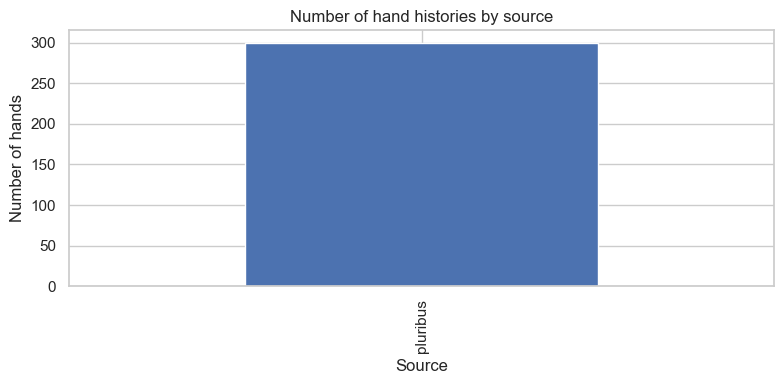

In [53]:
if features_df is not None:
    features_df["likely_dataset_source"].value_counts().plot(kind="bar", figsize=(8, 4))
    plt.title("Number of hand histories by source")
    plt.xlabel("Source")
    plt.ylabel("Number of hands")
    plt.tight_layout()
    plt.show()

This graph shows how many hand histories come from each source. It matters because the source tells us which dataset family we are currently exploring first.

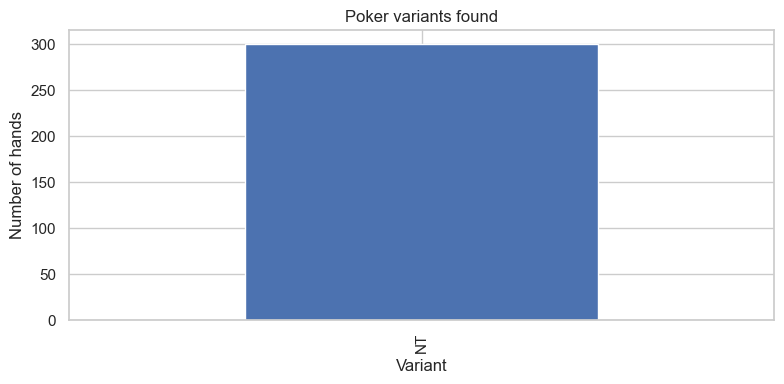

In [54]:
if features_df is not None:
    features_df["variant"].replace("", "unknown").value_counts().plot(kind="bar", figsize=(8, 4))
    plt.title("Poker variants found")
    plt.xlabel("Variant")
    plt.ylabel("Number of hands")
    plt.tight_layout()
    plt.show()

This graph shows which poker variants appear in the feature table. It matters because the project is especially interested in No-Limit Texas Hold'em style hands.

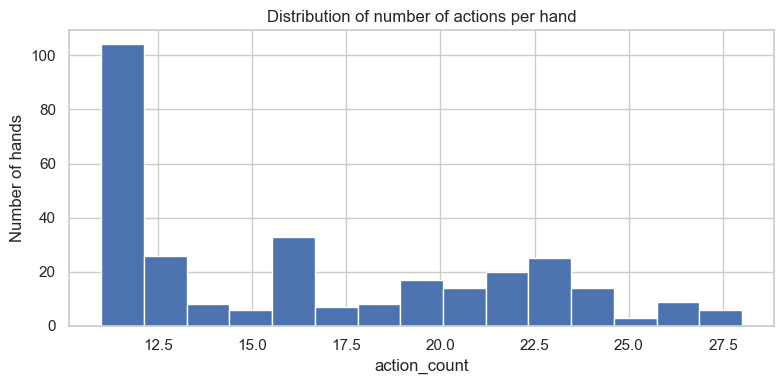

In [55]:
if features_df is not None:
    plt.figure(figsize=(8, 4))
    plt.hist(features_df["action_count"], bins=15)
    plt.title("Distribution of number of actions per hand")
    plt.xlabel("action_count")
    plt.ylabel("Number of hands")
    plt.tight_layout()
    plt.show()

This graph shows how much action is present in each hand. It matters because richer action sequences are more useful for later player-level parsing and decision analysis.

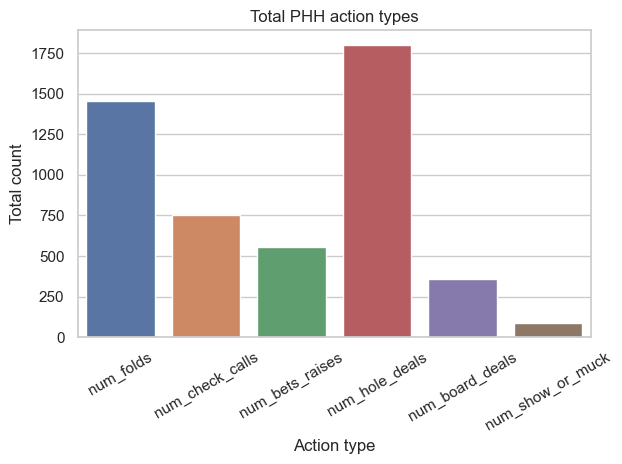

In [56]:
if features_df is not None:
    total_action_types_df = pd.DataFrame(
        {
            "action_type": [
                "num_folds",
                "num_check_calls",
                "num_bets_raises",
                "num_hole_deals",
                "num_board_deals",
                "num_show_or_muck",
            ],
            "total_count": [
                int(features_df["num_folds"].sum()),
                int(features_df["num_check_calls"].sum()),
                int(features_df["num_bets_raises"].sum()),
                int(features_df["num_hole_deals"].sum()),
                int(features_df["num_board_deals"].sum()),
                int(features_df["num_show_or_muck"].sum()),
            ],
        }
    )
    sns.barplot(data=total_action_types_df, x="action_type", y="total_count", hue="action_type", legend=False)
    plt.title("Total PHH action types")
    plt.xlabel("Action type")
    plt.ylabel("Total count")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

This graph shows which action families appear most often in the current feature table. It matters because it confirms whether the raw PHH files contain enough betting and dealing structure for future modeling.

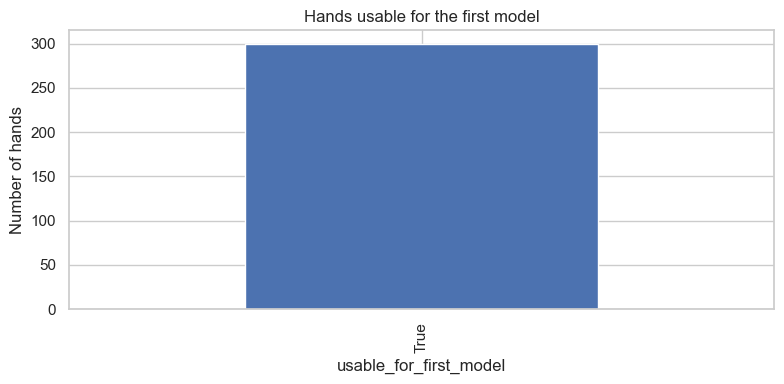

In [57]:
if features_df is not None:
    features_df["usable_for_first_model"].value_counts().plot(kind="bar", figsize=(8, 4))
    plt.title("Hands usable for the first model")
    plt.xlabel("usable_for_first_model")
    plt.ylabel("Number of hands")
    plt.tight_layout()
    plt.show()

This graph shows how many hands currently satisfy the first basic usability rules. It matters because these are the best candidates for the next parsing step.

## 9. First Hand-Level Feature Engineering Results

This is the first feature engineering step.

In [58]:
if features_df is not None:
    features_df.head(20)

In [59]:
if features_df is not None:
    features_df.describe(include=[np.number])

In [60]:
if features_df is not None:
    top_action_columns = [
        "source_relative_path",
        "hand_section_id",
        "variant",
        "likely_dataset_source",
        "player_count_estimated",
        "action_count",
        "num_folds",
        "num_check_calls",
        "num_bets_raises",
        "num_hole_deals",
        "num_board_deals",
        "num_show_or_muck",
        "usable_for_first_model",
    ]
    top_action_columns = [column for column in top_action_columns if column in features_df.columns]
    features_df.sort_values("action_count", ascending=False)[top_action_columns].head(20)

This table is not the final ML dataset. Each row currently represents one poker hand history. It helps identify which hands are rich enough to be parsed later into player-level and decision-level datasets.

## 10. Candidate Files for Next Parsing Step

In [61]:
if features_df is not None:
    candidate_files_df = features_df[features_df["usable_for_first_model"] == True].copy()
    sort_columns = [column for column in ["is_no_limit_texas_holdem", "action_count"] if column in candidate_files_df.columns]
    ascending_values = [False for _ in sort_columns]
    if sort_columns:
        candidate_files_df = candidate_files_df.sort_values(sort_columns, ascending=ascending_values)
    candidate_files_df.head(30)

These files are good candidates for the next parsing step because they contain No-Limit Texas Hold'em hands, actions, cards, and outcomes.

## 11. Manual Conclusions

- Number of raw poker files inspected:
- Main source used first:
- Main poker variant found:
- Are actions available?
- Are hole cards available?
- Are board cards available?
- Are final outcomes available?
- Is the data usable for a first win-probability model?
- Next technical step:

## 12. Next Step

The next notebook or script should build a player-level dataset where one row represents one player in one hand.

A possible future target is `player_won = 1` if the player won the hand, else `0`.

Possible future features include player position, starting stack, hole cards, number of opponents, action counts, board availability, and final stack difference.